In [1]:
import sys
sys.path.append('../')


from tqdm import tqdm
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from sympy import symbols
import utils_2Q_gate_zp as ut
import sigmaX_fidelity_optimize as zpX
import qutip as qt
import scqubits as scq
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scipy as sp
from scipy.ndimage import gaussian_filter
from joblib import Parallel, delayed
from IPython.display import display, Math

import networkx as nx

# Initialize Hilbert Space

In [2]:
EL        = 0.377 # GHz
EJ        = 6.013 # Soft Zero Pi (Gyenis)
EC_phi    = 1.142
EC_theta  = 0.092
E_CJ = 2 * EC_phi
E_C = 2./(1./EC_theta -1./EC_phi)

phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 100)
trunc1 = 300
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=30, truncated_dim=trunc1)
n_theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=trunc1)
n_phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=trunc1)
n_Phi = 2*np.pi * qt.Qobj(n_phi)
n_Theta = 2*np.pi * qt.Qobj(n_theta)

evals = 2*np.pi * zero_pi.eigenvals(evals_count=trunc1)
H0 = qt.Qobj(np.diag(evals))

w_trans_1 = {}
w_trans_2 = {}
core_states = {}
drive_term = {}

w_trans_1["phi"] = evals[9] - evals[0]
w_trans_2["phi"] = evals[9] - evals[2]
drive_term["phi"] = n_Phi
core_states["phi"] = [0, 2, 9]

w_trans_1["theta"] = evals[7] - evals[0]
w_trans_2["theta"] = evals[7] - evals[2]
drive_term["theta"] = n_Theta
core_states["theta"] = [0, 2, 7]

# Truncation Estimate

To estimate which transitions should be the most important, we can calculate a generalized rabi frequency for each transition

$$
\Omega_{ij} = \frac{(A n_{ij})^2}{(A n_{ij})^2 + \delta^2}
$$

where $A$ is the amplitude of the control pulse and $n_{ij} = \langle i | n | j \rangle$ is the drive matrix. $\delta$ is the detuning between the drive and the transition $\omega_d - \omega_{ij}$.


In [3]:
drives = ["phi", "theta"]
rabi_df = {}
rabi_freq = {}
A = 1
for drive in drives:
    rabi_freq[drive] = np.zeros((evals.size, evals.size))
    rabi_df[drive] = []
    for i in range(trunc1):
        for j in range(trunc1):
            if i >= j:
                continue
            n_ij = np.abs(drive_term[drive][i, j])
            # Assume very close to resonance driving -- not actually true
            delta = -0.001
            delta1 = abs(abs(w_trans_1[drive]) - abs(evals[i] - evals[j]) - delta)
            delta2 = abs(abs(w_trans_2[drive]) - abs(evals[i] - evals[j]) - delta)
            delta = min(delta1, delta2)
            Omega_ij = ((A*n_ij)**2) / ((A*n_ij)**2 + delta**2)
            rabi_freq[drive][i, j] = Omega_ij
            rabi_df[drive].append({"ij": f"{i}_{j}", "i": i, "j": j, "rabi": Omega_ij, "drive": drive})
    rabi_df[drive] = pd.DataFrame(rabi_df[drive])
    rabi_df[drive].index = rabi_df[drive]["ij"]

In [4]:
print("fraction of 0 rabi freq",
      "theta:", sum(rabi_df["theta"]["rabi"] == 0)/rabi_df["theta"].shape[0],
      "phi:", sum(rabi_df["phi"]["rabi"] == 0)/rabi_df["phi"].shape[0])

fraction of 0 rabi freq theta: 0.6358082497212932 phi: 0.6463322185061315


Now for each transition try to calculate the ``distance'' from the logical or intermediate states. Here I define that as the product of the rabi frequencies that get you there. To calculate that, use a graph where the nodes are the rows/columns and the weights on each edge are:

$$
W_{ij} = -\log(\Omega_{ij})
$$

Note that the edge is only added if $\Omega_{ij} > 0$. We can then use graph search algorithms to find the shortest path.

In [5]:
# Construct the graph
rabi_graph = {}
for drive in drives:
    rabi_graph[drive] = nx.Graph()
    for i in range(trunc1):
        for j in range(trunc1):
            if i >= j:
                continue
            Omega_ij = rabi_freq[drive][i,j]
            if Omega_ij > 0:
                rabi_graph[drive].add_edge(i, j, weight=-np.log(Omega_ij))  # specify edge data

In [ ]:
drive = "theta"
(i, j) = (5, 11)
shortest_path = ""
shortest_path_len = np.inf
for source in core_states[drive]:
        for target in (i, j):
            if source == target:
                continue
            path = nx.shortest_path(rabi_graph[drive],
                                    source=source, target=target,
                                    weight="weight") 
            path_len = nx.shortest_path_length(rabi_graph[drive],
                                                source=source, target=target,
                                                weight="weight")
            # Only consider paths where the last two in the path are
            # the states being considered in this transition
            # if i in path[-2:] and j in path[-2:] and path_len < shortest_path_len:
            if path_len < shortest_path_len:
                shortest_path_len = path_len
                shortest_path = ",".join([str(x) for x in path])

shortest_path, shortest_path_len

[0, 7, 11, 5] 0.5684161653477565
saved
[0, 7, 11] 0.54338065325991
saved
[2, 7, 11, 5] 0.5684075818143655
[2, 7, 11] 0.543372069726519
saved
[7, 11, 5] 0.5684068861277636
[7, 11] 0.5433713740399171
saved


('7,11', 0.5433713740399171)

In [7]:
def shortest_path_to_core(row):
    shortest_path = ""
    shortest_path_len = np.inf
    drive = row["drive"]
    i = row["i"]
    j = row["j"]
    for source in core_states[drive]:
        for target in (i, j):
            path = nx.shortest_path(rabi_graph[drive],
                                    source=source, target=target,
                                    weight="weight") 
            path_len = nx.shortest_path_length(rabi_graph[drive],
                                                source=source, target=target,
                                                weight="weight")
            # Only consider paths where the last two in the path are
            # the states being considered in this transition
            # if i in path[-2:] and j in path[-2:] and path_len < shortest_path_len:
            if path_len < shortest_path_len:
                shortest_path_len = path_len
                shortest_path = ",".join([str(x) for x in path])
    return shortest_path_len, shortest_path

# Find shortest path for every row of the dataframe
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=False, nb_workers=150)
res = {}
for drive in ["theta", "phi"]:
    res[drive] = rabi_df[drive].parallel_apply(shortest_path_to_core, axis=1)

INFO: Pandarallel will run on 150 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [8]:
for drive in drives:
    rabi_df[drive]["path"] = ""
    rabi_df[drive]["path_len"] = 0.0
    rabi_df[drive]["score"] = 0.0
    rabi_df[drive]["degree"] = -1
    rabi_df[drive]["first_leakage"] = -1
    for ij in rabi_df[drive]["ij"].values:
        if res[drive][ij][1] != "":
            rabi_df[drive].at[ij, "path"] = res[drive][ij][1]
            rabi_df[drive].at[ij, "path_len"] = np.exp(-res[drive][ij][0])
            rabi_df[drive].at[ij, "score"] = np.exp(-res[drive][ij][0])*rabi_df[drive].at[ij, "rabi"]
            rabi_df[drive].at[ij, "degree"] = res[drive][ij][1].count(",") + 1
            path = res[drive][ij][1].split(",")
            if path[-1] == ij[0]:
                path.append(ij[-1])
            else:
                path.append(ij[0])
            leakage_states = [x for x in path if int(x) not in core_states[drive]]
            if leakage_states:
                rabi_df[drive].at[ij, "first_leakage"] = int(leakage_states[0])
            else:
                rabi_df[drive].at[ij, "first_leakage"] = -1


# 

# States to keep

to try and estimate states to keep

In [27]:
contrib = {}
for drive in drives:
    contrib[drive] = {}
    for _, row in rabi_df[drive].iterrows():
        for key in ["i", "j"]:
            if row[key] not in contrib[drive]:
                contrib[drive][row[key]] = row.score
            else:
                if contrib[drive][row[key]] < row.score:
                    contrib[drive][row[key]] = row.score

In [28]:
order_to_keep = {}
sorted_contrib = {}
for drive in drives:
    sorted_contrib[drive] = sorted(contrib[drive].items(), key=lambda item: item[1], reverse=True)
    order_to_keep[drive] = [x[0] for x in sorted_contrib[drive]]
sorted_contrib["theta"][:30]

[(2, 0.9999993043136401),
 (7, 0.9999993043136401),
 (0, 0.9999907208230588),
 (4, 0.6567955331350471),
 (25, 0.656596420672993),
 (38, 0.6561964974893498),
 (1, 0.5963963186897048),
 (11, 0.580786898131273),
 (5, 0.566427103157407),
 (12, 0.5549922155567449),
 (23, 0.46288848786141557),
 (30, 0.2961069020736468),
 (8, 0.2711398859572336),
 (32, 0.2513606973781711),
 (46, 0.25106441112018296),
 (18, 0.2510330538831389),
 (27, 0.2344820147333174),
 (17, 0.23001186156197428),
 (47, 0.22374590603711556),
 (42, 0.20730587543205198),
 (82, 0.20605460239628276),
 (21, 0.19311561905350008),
 (65, 0.1904165699694754),
 (37, 0.18810821753802237),
 (64, 0.1874080866041481),
 (83, 0.17281446030795078),
 (102, 0.16656018858811836),
 (127, 0.16404177869725062),
 (103, 0.16130049358654563),
 (56, 0.15626616899861528)]

In [10]:
order_to_keep = {}
sorted_contrib = {}
for drive in drives:
    sorted_contrib[drive] = sorted(contrib[drive].items(), key=lambda item: item[1], reverse=True)
    order_to_keep[drive] = [x[0] for x in sorted_contrib[drive]]
sorted_contrib["theta"][:30]

[(7, 4.363339122970315),
 (11, 2.548675157250075),
 (25, 2.512481893749071),
 (12, 1.754859475402532),
 (38, 1.751689825148115),
 (0, 1.5965917218351302),
 (32, 1.5943392343835479),
 (2, 1.5583865585617247),
 (30, 1.5298750401200962),
 (5, 1.4420249593244276),
 (46, 1.3188242894024393),
 (27, 1.2208899997175215),
 (4, 1.2126840703367752),
 (82, 1.1766582122430023),
 (18, 1.174633324118424),
 (47, 1.1684563256079268),
 (1, 1.119802821044883),
 (8, 1.0572163808953623),
 (65, 1.0138624595176768),
 (23, 0.9154863423630243),
 (64, 0.9148995672351331),
 (48, 0.9131997935952432),
 (31, 0.8613781919343185),
 (83, 0.8502117611797161),
 (33, 0.8477930702872672),
 (45, 0.7991926510520561),
 (17, 0.780197339871716),
 (21, 0.7321789920901697),
 (103, 0.5983504021766435),
 (63, 0.526092047582881)]

## Also sort by matrix element for comparison

In [11]:
max_vals = {}
order_charge = {}
for drive in drives:
    max_vals[drive] = {}
    for i in range(trunc1):
        if i not in core_states[drive][:-1]:
            max_vals[drive][i] = max([np.abs(drive_term[drive][s, i]/(2*np.pi)) for s in core_states[drive]])

    max_vals[drive] = sorted(max_vals[drive].items(), key=lambda item: item[1], reverse=True)
    order_charge[drive] = [x[0] for x in max_vals[drive]]

max_vals["theta"][:20]


[(4, 1.9963805986677123),
 (8, 1.680931890286884),
 (11, 1.5471327505855181),
 (1, 1.3044291547555027),
 (5, 1.2618860950297839),
 (18, 0.5265822185057764),
 (16, 0.21111207838911888),
 (25, 0.20449750128672434),
 (7, 0.19081531840954893),
 (40, 0.1582053737937271),
 (31, 0.14563834037825402),
 (33, 0.11494673356847576),
 (12, 0.09881888394562985),
 (23, 0.09482552134016325),
 (21, 0.09135534829985792),
 (42, 0.08395586032705674),
 (37, 0.08173996465247234),
 (46, 0.0684163781625298),
 (38, 0.0513783053590689),
 (67, 0.050226182245491496)]

## $n_\theta$

In [12]:
rabi_df["theta"].sort_values(by="score", ascending=False).iloc[:30]

,ij,i,j,rabi,drive,path,path_len,score,degree,first_leakage
ij,,,,,,,,,,
2_7,2_7,2,7,0.999999,theta,2,1.000000,0.999999,1,-1
0_7,0_7,0,7,0.999991,theta,0,1.000000,0.999991,1,-1
4_7,4_7,4,7,0.656796,theta,7,1.000000,0.656796,1,4
7_25,7_25,7,25,0.656596,theta,7,1.000000,0.656596,1,5
25_38,25_38,25,38,0.999391,theta,"7,25",0.656596,0.656196,2,25
0_1,0_1,0,1,0.596396,theta,0,1.000000,0.596396,1,1
7_11,7_11,7,11,0.580787,theta,7,1.000000,0.580787,1,1
5_11,5_11,5,11,0.975275,theta,"7,11",0.580787,0.566427,2,11
12_25,12_25,12,25,0.845256,theta,"7,25",0.656596,0.554992,2,25


In [13]:
drive="theta"
nx.shortest_path(rabi_graph[drive],
                                    source=7, target=11,
                                    weight="weight"), nx.shortest_path_length(rabi_graph[drive],
                                                        source=7, target=11,
                                                        weight="weight") 

([7, 11], 0.5433713740399171)

In [14]:
drive="theta"
nx.shortest_path(rabi_graph[drive],
                                    source=7, target=5,
                                    weight="weight"), nx.shortest_path_length(rabi_graph[drive],
                                                        source=7, target=5,
                                                        weight="weight") 

([7, 11, 5], 0.5684068861277636)

In [15]:
rabi_df["theta"][rabi_df["theta"].i==18].sort_values(by="path_len", ascending=False)

,ij,i,j,rabi,drive,path,path_len,score,degree,first_leakage
ij,,,,,,,,,,
18_25,18_25,18,25,0.000000e+00,theta,"7,25",0.656596,0.000000e+00,2,25
18_38,18_38,18,38,7.254976e-02,theta,"7,25,38",0.656196,4.760690e-02,3,25
18_23,18_23,18,23,0.000000e+00,theta,"7,25,12,23",0.462888,0.000000e+00,4,25
18_30,18_30,18,30,6.637078e-01,theta,"7,11,30",0.296107,1.965285e-01,3,11
18_32,18_32,18,32,9.986965e-01,theta,"7,11,32",0.251361,2.510331e-01,3,11
...,...,...,...,...,...,...,...,...,...,...
18_122,18_122,18,122,8.758928e-07,theta,"7,11,32,18",0.251033,2.198780e-07,4,11
18_123,18_123,18,123,0.000000e+00,theta,"7,11,32,18",0.251033,0.000000e+00,4,11
18_124,18_124,18,124,3.196361e-08,theta,"7,11,32,18",0.251033,8.023924e-09,4,11


First leakage states

In [16]:
np.unique(rabi_df["theta"]["first_leakage"].values)

array([-1,  1,  3,  4,  5,  6,  8,  9, 11, 25])

States to include

## $n_\phi$

In [17]:
rabi_df["phi"].sort_values(by="path_len", ascending=False).iloc[:30]

,ij,i,j,rabi,drive,path,path_len,score,degree,first_leakage
ij,,,,,,,,,,
0_1,0_1,0,1,0.000000e+00,phi,0,1.0,0.000000e+00,1,1
2_206,2_206,2,206,0.000000e+00,phi,2,1.0,0.000000e+00,1,6
2_204,2_204,2,204,0.000000e+00,phi,2,1.0,0.000000e+00,1,4
2_203,2_203,2,203,0.000000e+00,phi,2,1.0,0.000000e+00,1,3
2_202,2_202,2,202,0.000000e+00,phi,2,1.0,0.000000e+00,1,-1
2_201,2_201,2,201,0.000000e+00,phi,2,1.0,0.000000e+00,1,1
2_200,2_200,2,200,5.876607e-12,phi,2,1.0,5.876607e-12,1,-1
2_199,2_199,2,199,0.000000e+00,phi,2,1.0,0.000000e+00,1,-1
2_198,2_198,2,198,2.427959e-11,phi,2,1.0,2.427959e-11,1,8


In [18]:
rabi_df["phi"]["first_leakage"].unique()

array([ 1, -1,  3,  4,  5,  6,  7,  8, 33, 10, 19])

In [19]:
sorted_contrib["phi"] = sorted(contrib["phi"].items(), key=lambda item: item[1], reverse=True)
order_to_keep["phi"] = [x[0] for x in sorted_contrib["phi"]]
sorted_contrib["phi"][:10]

[(33, 4.351097356015393),
 (69, 3.960746684357857),
 (55, 3.9224064719643477),
 (92, 3.6845363315984834),
 (9, 3.4176697137094503),
 (53, 3.0513765870255702),
 (76, 3.0008079746622784),
 (31, 2.7582033354828215),
 (194, 2.725443809740472),
 (100, 2.661007450219584)]

# Driving to test fidelity

## $n_\theta$

Keeping the first 300 states

In [20]:
def theta_test_pulse(hilbert_space):
    # tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [22, 0.21142888, 0.04991373, 0.002936, -0.00242995]
    # tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [30, 0.298429, 0.048571, -0.03174, -0.029243]
    tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [60, 0.15042571732968524, 0.04685021908945983, 0.03748943485669252, 0.04001032187908264]
    n_cpu = 150
    argz = [H0, drive_term["theta"], w_trans_1["theta"], w_trans_2["theta"], hilbert_space, n_cpu, tg,
        drive_amp_A, drive_amp_B, detune_A, detune_B, 0, 0]
    return ut.xgate_fidelity(argz)

f_300 = theta_test_pulse(list(np.arange(300)))
f_300

-2.2749806843430793

In [21]:
theta_test_pulse(sorted(set([0,2,7] + order_to_keep[drive][:100])))

-2.269928238897952

Plot keeping the first n states

In [ ]:
first_n_states = [10, 25, 35, 44, 50, 60, 70, 80, 90, 100, 120, 125, 150, 175, 200, 225, 250, 275, 300]
first_n_states = first_n_states
# fid = {}
drive = "theta"
# fid[drive] = {}
# fid[drive]["by_num"] = []
# fid[drive]["by_mat_elem"] = []
fid[drive]["by_estimate"] = []
for n in tqdm(first_n_states):
    # fid[drive]["by_num"].append(theta_test_pulse(list(np.arange(n))))
    # fid[drive]["by_mat_elem"].append(theta_test_pulse(sorted(set(core_states[drive] + order_charge[drive][:n]))))
    fid[drive]["by_estimate"].append(theta_test_pulse(sorted(set(core_states[drive] + order_to_keep[drive][:n]))))

100%|██████████| 19/19 [15:41<00:00, 49.56s/it] 


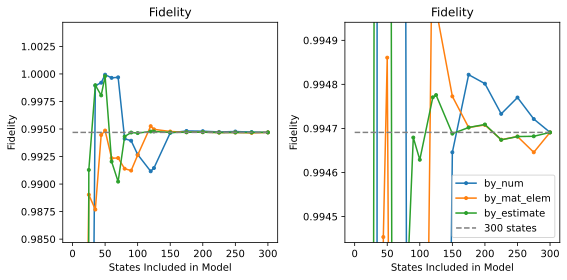

In [24]:
f, ax = plt.subplots(ncols=2, figsize=(8,4))
for estimate in ["by_num", "by_mat_elem", "by_estimate"]:
    ax[0].plot(first_n_states, 1-10**(np.array(fid["theta"][estimate])), label=estimate, marker=".")
    ax[1].plot(first_n_states, 1-10**(np.array(fid["theta"][estimate])), label=estimate, marker=".")

for i in range(2):
    ax[i].hlines(1-10**(f_300), 0, 300, color="gray", label="300 states", linestyles="--")
    ax[i].set_title("Fidelity")
    ax[i].set_ylabel("Fidelity")
    ax[i].set_xlabel("States Included in Model")
# plt.yscale("log")
ax[1].set_ylim(1-10**(f_300)-0.00025, 1-10**(f_300)+0.00025)
ax[0].set_ylim(1-10**(f_300)-0.01, 1-10**(f_300)+0.01)
plt.tight_layout()
plt.legend();

## Timing Test

In [44]:
from time import time
def xgate_fidelity_tg_test(argz, just_tg):
    [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, tg,
    drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B] = argz

    states = [qt.basis(len(hilbert_space), i) for i in range(len(hilbert_space))]
    H0_truc = ut.truncate_2(H0, hilbert_space)
    drive_truc = ut.truncate_2(drive_term, hilbert_space)
    H_qbt_drive = [H0_truc, [drive_truc, ut.drag_A],
                            [drive_truc, ut.drag_B],]

    pulse_args = {'drive_amp_A': drive_amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
             'alpha_A': alpha_A,
             'alpha_B': alpha_B }
    num=100* int(np.max([tg, len(hilbert_space) ]))
    tlist = np.linspace(0, tg, num)  # total time
    options =qt.Options(num_cpus=1, nsteps=100*num)

    if just_tg:
        prop = qt.propagator( H=H_qbt_drive,
                                t=tg,
                                args=pulse_args,
                                options=options,
                                num_cpus=n_cpu,
                                parallel=True,
                                )  # get the propagator at the final time step
    else:
        prop = qt.propagator( H=H_qbt_drive,
                                t=tlist,
                                args=pulse_args,
                                options=options,
                                num_cpus=n_cpu,
                                parallel=True,
                                )[-1]  # get the propagator at the final time step
    index_2 = hilbert_space.index(2)
    state_logi = [states[0], states[index_2]]
    Uc = qt.Qobj([ [prop.matrix_element(s1, s2) for s1 in state_logi]
            for s2 in state_logi  ])
    fidelity = qt.average_gate_fidelity(Uc, target=qt.sigmax())
    return np.log10(1-fidelity)

reps = 1
timing_res = {}
for n in [10, 50, 100, 150]:
    print(n)
    timing_res[n] = {}
    tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [22, 0.21142888, 0.04991373, 0.002936, -0.00242995]
    n_cpu = 1
    argz = [H0, drive_term["theta"], w_trans_1["theta"], w_trans_2["theta"], list(np.arange(n)), n_cpu, tg,
        drive_amp_A, drive_amp_B, detune_A, detune_B, 0, 0]
    for just_tg in [True, False]:
        timing_res[n][just_tg] = []
        for _ in tqdm(range(reps)):
            t0 = time()
            xgate_fidelity_tg_test(argz, just_tg)
            tf = time()
            timing_res[n][just_tg].append(t0-tf)

10


100%|██████████| 1/1 [00:08<00:00,  8.25s/it]


50


100%|██████████| 1/1 [01:46<00:00, 106.85s/it]


100


100%|██████████| 1/1 [09:20<00:00, 560.48s/it]


150


100%|██████████| 1/1 [30:25<00:00, 1825.97s/it]


In [45]:
timing_res

{10: {True: [-2.09787654876709], False: [-8.251343965530396]},
 50: {True: [-20.867820262908936], False: [-106.85077476501465]},
 100: {True: [-82.83928847312927], False: [-560.4802386760712]},
 150: {True: [-226.7179296016693], False: [-1825.96546792984]}}

In [52]:
y_tlist

array([[   -8.25134397],
       [ -106.85077477],
       [ -560.48023868],
       [-1825.96546793]])

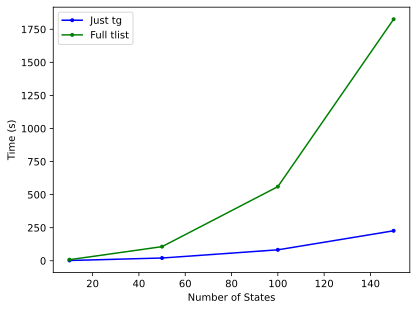

In [65]:
f, ax = plt.subplots()
w = 10
x = np.array(list(timing_res.keys()))
y_t0 = np.array([-timing_res[t][True][0] for t in x])
y_tlist = np.array([-timing_res[t][False][0] for t in x])

# ax.bar(x-w, y_t0, width=w, color='b', align='center', label="Just tg")
# ax.bar(x, y_tlist, width=w, color='g', align='center', label="Full tlist")
ax.plot(x, y_t0, marker=".", color='b', label="Just tg")
ax.plot(x, y_tlist, color='g', marker=".", label="Full tlist")
# ax.plot(x, y_tlist/y_t0, marker=".", color='b', label="Just tg")
plt.ylabel("Time (s)")
plt.xlabel("Number of States")
# plt.yscale("log")
plt.legend();

Compare with Krylov

In [22]:
sorted([0,2] + order_charge["theta"][:10])

[0, 1, 2, 5, 7, 12, 17, 21, 27, 38, 41, 48]

In [23]:
sorted([0,2] + order_to_keep["theta"][:10])

[0, 1, 2, 7, 11, 23, 25, 30, 32, 38, 46, 82]

In [28]:
[fid["theta"][x] for x in ["by_num", "by_mat_elem", "by_estimate"]]

[[-1.1389809640975463], [-0.1761464534039157], [-0.18354509331491164]]

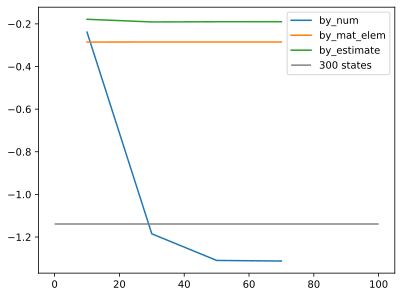

In [ ]:
thresh = 0.01
hspace_indirect = [0, 2]
for s in hspace_indirect:
    for i in range(trunc1):
        if np.abs(drive_term[s, i]/(2*np.pi)) > thresh and i not in hspace_indirect:
            hspace_indirect.append(i)
hspace_indirect.sort()
hspace_full = np.arange(trunc1)

hilbert_space = hspace_indirect
truc2 = len(hilbert_space)
print('threshold=', thresh)
print('num of truncation =', truc2)
print('hilbert_space :')
dim = 10
data = hilbert_space
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')



threshold= 0.01
num of truncation = 159
hilbert_space :
0, 2, 3, 4, 8, 9, 10, 11, 15, 16 ,
18, 19, 20, 23, 24, 25, 28, 31, 33, 35 ,
37, 39, 40, 42, 43, 46, 47, 49, 51, 53 ,
55, 56, 57, 60, 62, 64, 66, 67, 69, 70 ,
73, 76, 77, 79, 81, 83, 85, 86, 88, 91 ,
92, 95, 96, 98, 100, 101, 102, 104, 106, 108 ,
110, 112, 113, 116, 118, 120, 121, 123, 126, 128 ,
130, 132, 133, 136, 137, 139, 141, 143, 145, 146 ,
148, 151, 153, 154, 156, 158, 159, 162, 164, 166 ,
167, 169, 170, 173, 174, 176, 179, 181, 183, 185 ,
186, 188, 190, 191, 194, 196, 198, 200, 202, 205 ,
206, 208, 209, 212, 213, 216, 218, 220, 222, 223 ,
226, 227, 229, 230, 232, 234, 237, 239, 241, 242 ,
245, 246, 248, 250, 252, 253, 255, 257, 259, 262 ,
264, 265, 267, 269, 271, 273, 275, 276, 279, 281 ,
282, 283, 286, 288, 290, 291, 292, 294, 297 ,


#### Charge matrix element

In [ ]:
w_trans = []
trans = []
trans_mat = []
# state_good = [0, 2, 7, 25, 1, 4,5] # theta
state_good = [0, 2, 9,10, 19, 33,47] # phi
for state_i in state_good:
    i = hspace_indirect.index(state_i)
    for j, state_j in enumerate(hspace_indirect):
        if np.abs(drive_truc[i, j]/(2*np.pi)) > thresh and state_i != state_j:
            f = np.round( np.abs(evals[state_i] - evals[state_j]),8 )
            if f not in w_trans:
                w_trans.append(f)
                transition = str(state_i) + '-' + str(state_j)
                trans.append(transition)
                trans_mat.append( np.round( np.abs(drive_truc[i, j]/(2*np.pi)) , 3))
# for i, _ in enumerate(trans):
#     print(trans[i], w_trans[i], trans_mat[i])

sort_idx = np.argsort(w_trans)
w_trans = np.sort(np.round(w_trans, 3))
trans_mat = [np.round(trans_mat[i],3) for i in sort_idx]
trans = [trans[i] for i in sort_idx]
# for i, _ in enumerate(trans):
#     print(i, trans[i], w_trans[i], trans_mat[i])

Text(0.5, 1.0, '$n_\\phi:\\psi_0=$[0, 2, 9, 10, 19, 33, 47]')

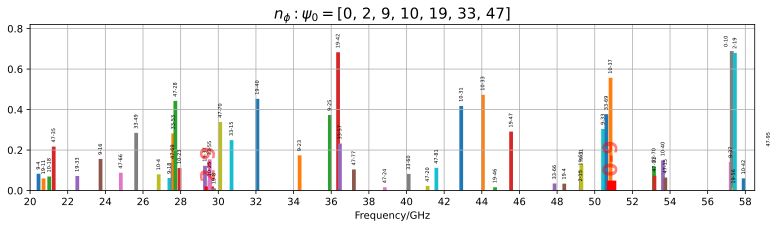

In [ ]:
fig, ax = plt.subplots(figsize=(13,3))
y_shift = 0.02
state_overlap = ['0-10']
x_shift = [-0.3]
x_min, x_max = 20, 60
for i,_ in enumerate(w_trans):
    if x_min < w_trans[i] < x_max:# and trans_mat[i] < 2:
        if trans[i] in ['0-9', '2-9']:
            plt.bar(w_trans[i], trans_mat[i], width=0.5, color='red')
            plt.text(w_trans[i], trans_mat[i] +y_shift, trans[i], ha="center", va="bottom", rotation=90, fontsize=20, fontweight='bold', color='red', alpha=0.5)
        elif trans[i] in state_overlap:
            plt.bar(w_trans[i], trans_mat[i], width=0.2)
            plt.text(w_trans[i]-0.3, trans_mat[i] +y_shift, trans[i], ha="center", va="bottom", rotation=90, fontsize=5)
        else:
            plt.bar(w_trans[i], trans_mat[i], width=0.2)
            plt.text(w_trans[i], trans_mat[i] +y_shift, trans[i], ha="center", va="bottom", rotation=90, fontsize=5)

plt.ylim(0,0.82)
plt.xlim(x_min,x_max-1.5)
plt.xlabel(f'Frequency/GHz')
plt.grid()
plt.xticks(np.arange(x_min, x_max, 2))  # Set custom x-axis ticks
# plt.ylabel('Max population during X gate')
plt.title(r'$n_\phi:\psi_0=$'+f'{state_good}', fontsize=15)

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

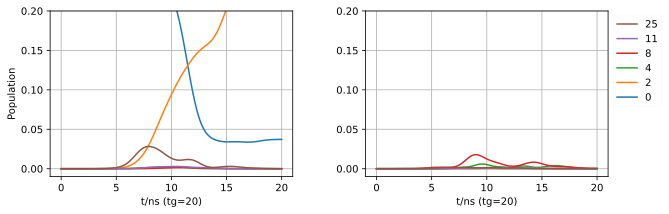

In [ ]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
#ax[0].plot(tlist, drive)
# fig.suptitle(state0+'-->'+state1 + ';  A=%.4f; '%drive_amp + '$\omega_d$=%.4f'%trans_freq )
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
state_god = [0,2,1,4,5,7,8,11,25]
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        if hilbert_space[state] in state_god:
            ax[jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) , label=r"%d"%hilbert_space[state])
    ax[jdx].set_ylim(-0.01,0.2)
    ax[jdx].grid()
    ax[jdx].set_xlabel(f't/ns (tg={tg})')
    # ax[idx][jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')

# ax[1].plot(tlist, gaussian_filter( np.array(result[1].expect[1] + result[1].expect[3] + result[1].expect[4]).flatten(), 3) , label=r"4+5")

# ax[1].set_title(f'fidelity={fidel}')
ax[0].set_ylabel('Population')
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend( handles[::-1],labels[::-1], ncol=1,
            loc='upper left',
            bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)

In [ ]:
pop_integral = np.array(pop_integral)
hilbert_space = np.array(hilbert_space)
# Get the indices of the 45 largest elements
top_45_indices = np.argpartition(pop_integral, -45)[-45:]

# Sort these indices based on the actual values in descending order
top_45_indices = top_45_indices[np.argsort(-pop_integral[top_45_indices])]
print('tg=',tg)
# print("Indices of 45 states with largest population integral:", hilbert_space[top_45_indices])
print("Indices sorted:")
dim = 10
data = np.sort(hilbert_space[top_45_indices])
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')
# print("population integral values:", pop_integral[top_45_indices])

tg= 20
Indices sorted:
0, 2, 9, 10, 15, 19, 23, 25, 28, 31 ,
33, 37, 40, 42, 46, 47, 51, 55, 57, 60 ,
64, 66, 69, 70, 83, 85, 91, 98, 102, 113 ,
116, 123, 128, 136, 151, 159, 170, 174, 185, 196 ,
209, 226, 252, 283, 294 ,


In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

#### $n_\phi$

Text(0.5, 0, 'Frequency/GHz')

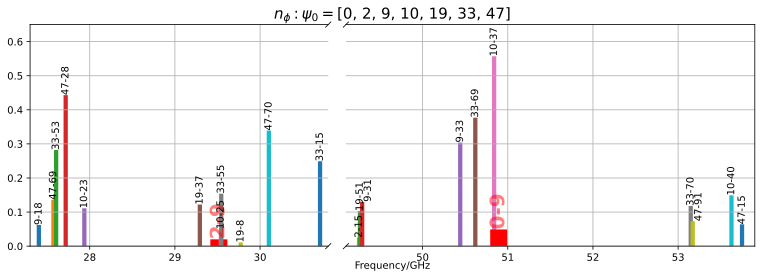

In [ ]:
width = 0.8
y_shift = 0.0
state_overlap = ['47-91', '9-31']
x_shift = [-0.3,-0.3]
xlims = ((27.3, 30.8), (49.1, 53.9))
fig = plt.figure(figsize=(13, 4))
bax = brokenaxes(xlims=xlims, wspace=0.05, d=0.004, despine=False, hspace=0.05)

for i in range(len(w_trans)):
    for xlim in xlims:
        if xlim[0] < w_trans[i] < xlim[1]:
            if trans[i] in ['0-9', '2-9']:
                bax.bar(w_trans[i], trans_mat[i], width=0.2, color='red')
                bax.text(w_trans[i], trans_mat[i] +y_shift, trans[i], ha="center", va="bottom", rotation=90, fontsize=20, fontweight='bold', color='red', alpha=0.5)
            elif trans[i] in state_overlap:
                bax.bar(w_trans[i], trans_mat[i], width=0.05)
                bax.text(w_trans[i]+0.07, trans_mat[i] +y_shift, trans[i], ha="center", va="bottom", rotation=90, fontsize=10)
            else:
                bax.bar(w_trans[i], trans_mat[i], width=0.05)
                bax.text(w_trans[i], trans_mat[i] +y_shift, trans[i], ha="center", va="bottom", rotation=90, fontsize=10)
bax.set_ylim(0, 0.65)
bax.grid()
bax.set_title(r'$n_\phi:\psi_0=$'+f'{state_good}', fontsize=15)
bax.set_xlabel(f'Frequency/GHz')
# plt.grid()
# plt.xticks(np.arange(x_min, x_max, 2))  # Set custom x-axis ticks

#### Matrix element table

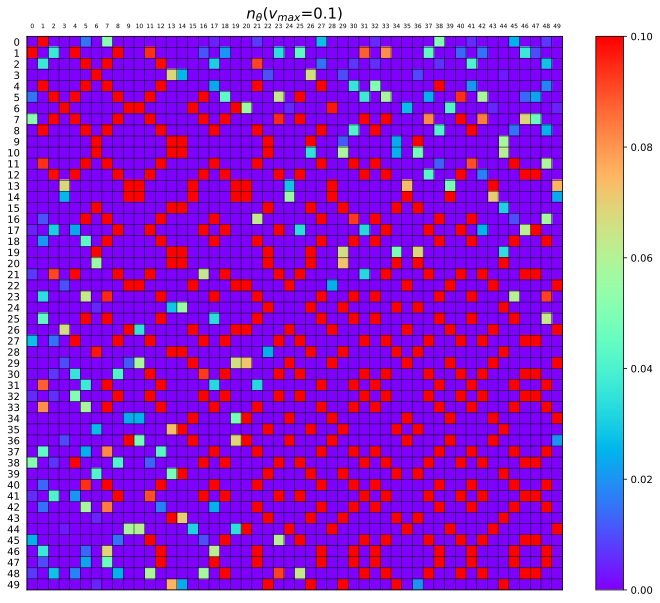

In [ ]:
vmax = 0.1
truc2 = 50
fig, ax = plt.subplots(figsize=(12,10))
font_size = 15
plt.imshow(np.abs(n_theta[:truc2,:truc2]), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'$n_{\theta}$($v_{max}$='+f'{vmax})' , pad=5,fontsize=font_size)
ax.set_xticks(np.arange(0, truc2, 1), np.arange(0, truc2, 1), fontsize=6)
ax.set_yticks(np.arange(0, truc2, 1), np.arange(0, truc2, 1))
# ax.set_yticks(np.arange(0, dim_plot, 1),["|0>","|1>","|2>","|3>","|4>","|5>","|6>","|7>","|8>","|9>"])
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar()
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

#### only consider leakage directly from logical states

In [ ]:
thresh= 1e-0
hspace_comp = [0,1]
hspace_direct = hspace_comp
for i in hspace_comp:
    for j in range(truc2):
        if np.abs(n_theta[i,j]) > thresh:
            hspace_direct.append(j)
print('threshold=', thresh)
print('num of truncation (direct) =', len(hspace_direct))
print('hilbert_space :')
dim = 10
data = hspace_direct
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

KeyboardInterrupt: 

#### consider leakage directly and indirectly from logical states

threshold= [1e-8,0.1]
num of truncation = 49
hilbert_space :
0, 3, 5, 21, 1, 2, 10, 16, 20, 12 ,
14, 40, 45, 55, 7, 8, 9, 28, 32, 36 ,
44, 29, 31, 35, 67, 74, 69, 81, 25, 26 ,
27, 57, 60, 64, 71, 76, 58, 62, 90, 93 ,
97, 98, 49, 52, 83, 87, 85, 94, 99 ,

In [ ]:
# logi_index = [order_sort.index(x) for x in logi_space]
threshold = 1e-1
hspace_charge = [0, 3, 5, 21]
for i in hspace_charge:
    for j in range(n_theta1_dress.shape[0]):
        if np.abs(n_theta2_dress[i,j]) > threshold and j not in hspace_charge:
            hspace_charge.append(j)
print('threshold=', threshold)
print('num of truncation =', len(hspace_charge))
print('hilbert_space :')
dim = 10
data = hspace_charge
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

threshold= 0.1
num of truncation = 49
hilbert_space :
0, 3, 5, 21, 1, 2, 10, 16, 20, 12 ,
14, 40, 45, 55, 7, 8, 9, 28, 32, 36 ,
44, 29, 31, 35, 67, 74, 69, 81, 25, 26 ,
27, 57, 60, 64, 71, 76, 58, 62, 90, 93 ,
97, 98, 49, 52, 83, 87, 85, 94, 99 ,


In [ ]:
# truc = 300
# drive_phi = True
# drive_theta = False
# [H0, drive_term, w_trans_1, w_trans_2] = ut.zero_pi_intialize(drive_phi, drive_theta, truncation=truc)

#### Find truncation from charge matrix element

In [ ]:
thresh = 0.0001
hspace_charge = [0, 2]
for s in hspace_charge:
    for i in range(truc):
        if np.abs(drive_term[s, i]/(2*np.pi)) > thresh and i not in hspace_charge:

            hspace_charge.append(i)
hspace_charge.sort()
print('drive_phi=', drive_phi, '; drive_theta = ', drive_theta)
print('nphi threshold=', thresh)
print('num of truncation =', len(hspace_charge))
print('hilbert_space :')
dim = 10
data = hspace_charge
for i in range(0, len(data), dim):
    print(', '.join(map(str, np.round(data[i:i+dim], 8) )), ',')


drive_phi= False ; drive_theta =  True
nphi threshold= 0.0001
num of truncation = 161
hilbert_space :
0, 1, 2, 3, 6, 7, 9, 10, 11, 13 ,
15, 16, 17, 19, 21, 22, 25, 26, 28, 29 ,
32, 33, 36, 37, 40, 42, 43, 48, 49, 50 ,
51, 52, 56, 57, 59, 60, 61, 62, 63, 68 ,
69, 71, 72, 74, 75, 77, 81, 84, 85, 87 ,
88, 89, 90, 96, 97, 98, 99, 101, 104, 105 ,
106, 110, 111, 112, 113, 117, 118, 119, 120, 124 ,
125, 128, 129, 132, 133, 136, 137, 139, 140, 144 ,
145, 147, 148, 151, 152, 156, 157, 159, 160, 161 ,
163, 166, 167, 169, 170, 174, 175, 176, 179, 180 ,
181, 182, 187, 188, 189, 192, 193, 198, 199, 200 ,
201, 202, 207, 208, 212, 213, 215, 216, 220, 221 ,
226, 227, 228, 229, 232, 233, 236, 237, 238, 239 ,
244, 245, 246, 247, 248, 249, 250, 251, 256, 257 ,
258, 261, 262, 263, 264, 269, 270, 271, 272, 273 ,
274, 277, 278, 281, 282, 290, 291, 294, 295, 298 ,
299 ,


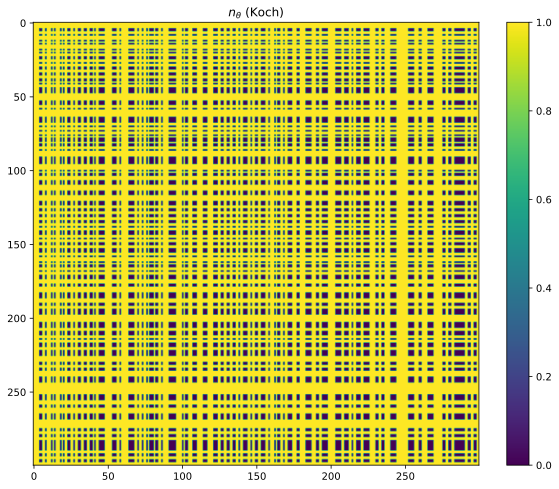

In [ ]:
matrix = np.zeros((truc, truc))
matrix[hspace_charge, :] = 1  # 设置指定行
matrix[:, hspace_charge] = 1  # 设置指定列

fig, ax = plt.subplots(figsize=(10, 8))
plt.imshow(matrix, cmap='viridis', aspect='auto')
plt.title(r'$n_\theta$ (Koch)')
plt.colorbar()
plt.show()


In [ ]:
thresh = 0.0001
hspace_charge = [0, 2]
for s in hspace_charge:
    for i in range(truc):
        if np.abs(drive_term[s, i]/(2*np.pi)) > thresh and i not in hspace_charge:
            hspace_charge.append(i)
hspace_charge.sort()
print('drive_phi=', drive_phi, '; drive_theta = ', drive_theta)
print('nphi threshold=', thresh)
print('num of truncation =', len(hspace_charge))
print('hilbert_space :')
dim = 10
data = hspace_charge
for i in range(0, len(data), dim):
    print(', '.join(map(str, np.round(data[i:i+dim], 8) )), ',')


drive_phi= False ; drive_theta =  True
nphi threshold= 0.0001
num of truncation = 29
hilbert_space :
0, 1, 2, 4, 5, 7, 8, 11, 12, 16 ,
17, 18, 21, 23, 25, 27, 30, 31, 32, 33 ,
37, 38, 40, 41, 42, 45, 46, 47, 48 ,


### drive $n_\theta$ - get fidelity for 100 levels

In [ ]:
tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [22, 0.21142888, 0.04991373, 0.002936, -0.00242995]
truc1=50
hilbert_space = np.arange(truc1)
arg = [drive_amp_A, drive_amp_B, detune_A, detune_B]
args = (H0, drive_term, tg, w_trans_1, w_trans_2, hilbert_space)
f_300 = ut.xgate_fidelity_optimize(arg, *args)
f_300

-1.1384548235470549

### drive $n_\theta$ - get fidelity by removing a level (parallel)

1. truc=50    lg(1-F)=-1.6015
2. truc=100 lg(1-F)=-1.2961

In [ ]:
args = (H0, drive_term, tg, w_trans_1, w_trans_2, hspace_charge)
f_157 = ut.xgate_fidelity_optimize(arg, *args)
f_157

-1.138542318012815

In [ ]:
print(1- 10**f_300)
print(1- 10**f_157)

0.9272981978394608
0.9273128431202388


In [ ]:
hspace = np.arange(truc1)
args = [H0, drive_term, w_trans_1, w_trans_2, hspace]
f_theta = Parallel(n_jobs=len(param_theta), verbose=1)(delayed(ut.xgate_fidelity_arg5)(arg, args)
                                            for arg in para_tot)

print('\nfidelity = ')
dim = 5
data = f_theta
for i in range(0, len(data), dim):
    print(', '.join(map(str, np.round(data[i:i+dim], 6) )), ',')

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:  1.1min remaining:  8.0min



fidelity = 
-1.291915, -0.912229, -1.662145, -1.478222, -1.175574 ,
-1.569847, -0.7981, -2.113408, -1.426514, -2.26666 ,
-2.140774, -0.872873, -2.582661, -2.208428, -2.356036 ,
-2.694133 ,


[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:  3.8min finished


In [ ]:
=

In [ ]:
level_start = np.arange(0, truc1, step=1)
levels = np.arange(3, truc1, step=1)
hspace_grid = []
for level in levels:
    hspace_grid.append(np.delete(level_start, level))

f_theta = Parallel(n_jobs=len(levels), verbose=1)(delayed(ut.get_fidelity_given_hspace)(hspace, argz)
                                            for hspace in hspace_grid)
# print('\nfidelity = ')
# dim = 5
# data = f_theta
# for i in range(0, len(data), dim):
#     print(', '.join(map(str, np.round(data[i:i+dim], 6) )), ',')

####  drive $n_\theta$ - get fidelity given levels

In [ ]:
f_theta = [
    -1.29606479, -0.23390096, -0.20476632, -1.29606491 ,
    -0.17794121, -0.39072164, -1.29606474, -1.29606504 ,
    -0.25686453, -0.78325307, -1.29606545, -1.29606489 ,
    -1.29606532, -1.21461004, -1.16453124, -0.34342454 ,
    -1.29606494, -1.29606572, -1.25056463, -1.29606549 ,
    -1.27048983, -1.2960659, -0.27666921, -1.29606546 ,
    -0.8518462, -1.29606648, -1.29606641, -1.26151253 ,
    -1.23555753, -1.35343648, -1.32242524, -1.2960678 ,
    -1.29606765, -1.29606844, -1.2160092, -0.91022508 ,
    -1.29606873, -1.46763772, -1.3565264, -1.22692592 ,
    -1.29606768, -1.29606949, -1.07256834, -1.35222928 ,
    -1.30550213, -1.06191345, -1.29606506, -1.29606506 ,
    -1.2604177, -1.2791995, -1.29606396, -1.29606262 ,
    -1.29606132, -1.29710799, -1.2960652, -1.29606548 ,
    -1.40267125, -1.2960673, -1.29606636, -1.23016757 ,
    -1.25546211, -1.28399308, -1.28950719, -1.29606756 ,
    -1.29688577, -1.29606185, -1.29605482, -1.29606973 ,
    -1.29606953, -1.45108441, -1.4510346, -1.38057674 ,
    -1.29606459, -1.31629272, -1.29605089, -1.2971586 ,
    -1.28798824, -1.29596135, -1.29605682, -1.29263129 ,
    -1.28502376, -1.29607003, -1.29521176, -1.29605065 ,
    -1.18889455, -1.19505596, -1.29606712, -1.30140701 ,
    -1.29606483, -1.32068015, -1.31851872, -1.29607053 ,
    -1.29607052, -1.30625864, -1.30182707, -1.30069849 ,
    -1.29606547 ,
 ]
level_start = np.arange(0, truc1, step=1)
levels = np.arange(3, truc1, step=1)
hspace = [0, 1, 2]
f_100 = -1.2960641216930395
for level, f in zip(levels, f_theta):
    if np.abs(f - np.round(f_100, 6)) >= 0.00001:
        hspace.append(level)
f_truc = ut.get_fidelity_given_hspace(hspace, argz)
print('fidelity =', f_truc)
print('num of truncation =', len(hspace))
dim = 10
data = hspace
for i in range(0, len(data), dim):
    print(', '.join(map(str, np.round(data[i:i+dim], 8) )), ',')
# len(hspace) = 58
# hspace_charge = [
# 0, 1, 2, 4, 5, 7, 8, 11, 12, 16 ,
# 17, 18, 21, 23, 25, 27, 30, 31, 32, 33 ,
# 37, 38, 40, 41, 42, 45, 46, 47, 48, 51 ,
# 52, 56, 59, 62, 63, 64, 65, 67, 72, 73 ,
# 74, 76, 77, 78, 79, 80, 82, 83, 85, 86 ,
# 87, 88, 90, 92, 93, 96, 97, 98 ,
#     ]
print('Difference to the 100 levels:', np.round(10**(f_100) - 10**(f_truc), 8))

fidelity = -1.2960372768639832
num of truncation = 58
0, 1, 2, 4, 5, 7, 8, 11, 12, 16 ,
17, 18, 21, 23, 25, 27, 30, 31, 32, 33 ,
37, 38, 40, 41, 42, 45, 46, 47, 48, 51 ,
52, 56, 59, 62, 63, 64, 65, 67, 72, 73 ,
74, 76, 77, 78, 79, 80, 82, 83, 85, 86 ,
87, 88, 90, 92, 93, 96, 97, 98 ,
Difference to the 100 levels: -3.13e-06


In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

####  drive $n_\theta$ - get fidelity by sweeping truncation

In [ ]:
# truc_vec = np.arange(150,250, 50)
tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [20, 0.239886, 0.0551455, -0.0051449, -0.00191928] # truc=50
fidel = []
for truc in tqdm([truc]):
    zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=dEJ,
                            ng=ng, flux=0., ncut=30, truncated_dim=truc)
    n_theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truc)
    n_phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truc)
    evals = 2*np.pi * zero_pi.eigenvals(evals_count=truc)
    H0 = qt.Qobj(np.diag(evals))
    n_Phi = 2*np.pi * qt.Qobj(n_phi)
    n_Theta = 2*np.pi * qt.Qobj(n_theta)
    states = [qt.basis(truc, i) for i in range(truc)]

    H_qbt_drive = [H0,  [n_Theta, ut.drive_gauss_A],
                        [n_Theta, ut.drive_gauss_B],]
    w_trans_1 = evals[7] - evals[0]
    w_trans_2 = evals[7] - evals[2]
    args = (tg, w_trans_1, w_trans_2, states, H_qbt_drive)
    arg_de = (drive_amp_A, drive_amp_B, detune_A, detune_B)
    fidel.append(ut.get_fidelity_x(arg_de, *args))
fidel = np.array(fidel)
# print('truncation = ', truc_vec.tolist())
print('fidelity = ', np.round(fidel.tolist(), 4))
# truncation =  [50, 60, 70, 80, 90, 100]
# fidelity =  [-4.02, -3.32, -3.39, -2.07, -2.05, -1.97]

100%|██████████| 1/1 [01:08<00:00, 68.98s/it]

fidelity =  [-1.2961]


In [ ]:
# truc_vec = np.arange(150,250, 50)
tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [20, 0.239886, 0.0551455, -0.0051449, -0.00191928] # truc=50
fidel = []
for truc in tqdm([truc]):
    zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=dEJ,
                            ng=ng, flux=0., ncut=30, truncated_dim=truc)
    n_theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truc)
    n_phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truc)
    evals = 2*np.pi * zero_pi.eigenvals(evals_count=truc)
    H0 = qt.Qobj(np.diag(evals))
    n_Phi = 2*np.pi * qt.Qobj(n_phi)
    n_Theta = 2*np.pi * qt.Qobj(n_theta)
    states = [qt.basis(truc, i) for i in range(truc)]

    H_qbt_drive = [H0,  [n_Theta, ut.drive_gauss_A],
                        [n_Theta, ut.drive_gauss_B],]
    w_trans_1 = evals[7] - evals[0]
    w_trans_2 = evals[7] - evals[2]
    args = (tg, w_trans_1, w_trans_2, states, H_qbt_drive)
    arg_de = (drive_amp_A, drive_amp_B, detune_A, detune_B)
    fidel.append(ut.get_fidelity_x(arg_de, *args))
fidel = np.array(fidel)
# print('truncation = ', truc_vec.tolist())
print('fidelity = ', np.round(fidel.tolist(), 4))
# truncation =  [50, 60, 70, 80, 90, 100]
# fidelity =  [-4.02, -3.32, -3.39, -2.07, -2.05, -1.97]

100%|██████████| 1/1 [01:26<00:00, 86.39s/it]

fidelity =  [-1.2961]


In [ ]:
=

### drive $n_\phi+n_\theta$

In [ ]:
truc_vec = np.array([10]) # np.arange(40,100, 10)
tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [20, 0.09871602296401119, 0.20900225470826742, 0.22214075955138304, 0.22595164441346902]
# [100, 0.14515, 0.12585, -0.09084, -0.068318] # truc=50

fidel = []
for truc in tqdm(truc_vec):
    zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=dEJ,
                            ng=ng, flux=0., ncut=30, truncated_dim=truc)
    n_theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truc)
    n_phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truc)
    evals = 2*np.pi * zero_pi.eigenvals(evals_count=truc)
    H0 = qt.Qobj(np.diag(evals))
    n_Phi = 2*np.pi * qt.Qobj(n_phi)
    n_Theta = 2*np.pi * qt.Qobj(n_theta)
    states = [qt.basis(truc, i) for i in range(truc)]
    H_qbt_drive = [H0,  [0.976*n_Phi+ 0.024*n_Theta, ut.drive_gauss_A],
                        [0.976*n_Phi+ 0.024*n_Theta, ut.drive_gauss_B],]
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    args = (tg, w_trans_1, w_trans_2, states, H_qbt_drive)
    arg_de = (drive_amp_A, drive_amp_B, detune_A, detune_B)
    fidel.append(ut.get_fidelity_x(arg_de, *args))
    print('log of gate error = ', fidel)
fidel = np.array(fidel)
print('truncation = ', truc_vec.tolist())
print('log of gate error = ', np.round(fidel.tolist(), 2))
# truncation =  [50, 60, 70, 80, 90, 100]
# fidelity =  [-4.02, -3.32, -3.39, -2.07, -2.05, -1.97]

100%|██████████| 1/1 [00:01<00:00,  1.28s/it]

log of gate error =  [-0.17687082013375752]
truncation =  [10]
log of gate error =  [-0.18]


In [ ]:
hilbert_space = [0, 2]
for s in hilbert_space:
    print('s=', s)
    for i in range(truc):
        if np.abs((0.976*n_phi+ 0.024*n_theta)[s, i]) > thresh and i not in hilbert_space:
            hilbert_space.append(i)
    print(len(hilbert_space), hilbert_space)

hilbert_space.sort()
print(len(hilbert_space), hilbert_space)

s= 0
16 [0, 2, 1, 9, 10, 15, 20, 24, 28, 35, 53, 55, 57, 66, 69, 81]
s= 2
22 [0, 2, 1, 9, 10, 15, 20, 24, 28, 35, 53, 55, 57, 66, 69, 81, 5, 19, 39, 43, 91, 95]
s= 1
38 [0, 2, 1, 9, 10, 15, 20, 24, 28, 35, 53, 55, 57, 66, 69, 81, 5, 19, 39, 43, 91, 95, 4, 6, 13, 14, 22, 26, 34, 36, 44, 50, 54, 58, 61, 75, 80, 89]
s= 9
61 [0, 2, 1, 9, 10, 15, 20, 24, 28, 35, 53, 55, 57, 66, 69, 81, 5, 19, 39, 43, 91, 95, 4, 6, 13, 14, 22, 26, 34, 36, 44, 50, 54, 58, 61, 75, 80, 89, 8, 11, 16, 18, 23, 25, 31, 33, 37, 40, 42, 46, 47, 56, 62, 64, 73, 76, 79, 83, 85, 92, 98]
s= 10
64 [0, 2, 1, 9, 10, 15, 20, 24, 28, 35, 53, 55, 57, 66, 69, 81, 5, 19, 39, 43, 91, 95, 4, 6, 13, 14, 22, 26, 34, 36, 44, 50, 54, 58, 61, 75, 80, 89, 8, 11, 16, 18, 23, 25, 31, 33, 37, 40, 42, 46, 47, 56, 62, 64, 73, 76, 79, 83, 85, 92, 98, 51, 88, 96]
s= 15
65 [0, 2, 1, 9, 10, 15, 20, 24, 28, 35, 53, 55, 57, 66, 69, 81, 5, 19, 39, 43, 91, 95, 4, 6, 13, 14, 22, 26, 34, 36, 44, 50, 54, 58, 61, 75, 80, 89, 8, 11, 16, 18, 23, 25, 31, 

### drive $n_\phi$

In [ ]:
tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [100,  0.22347715,  0.2959175,  -0.09120307, -0.09866836]
# [20, 0.23727472360716756, 0.05702996586746281, -0.011634756539731306, -0.008421158022791796]
w_trans_1 = evals[9] - evals[0]
w_trans_2 = evals[9] - evals[2]
H_qbt_drive = [H0,  [n_Phi, ut.drive_gauss_A],
                    [n_Phi, ut.drive_gauss_B],]
args = (tg, w_trans_1, w_trans_2, states, H_qbt_drive)
arg_de = (drive_amp_A, drive_amp_B, detune_A, detune_B)
fidel = ut.get_fidelity_x(arg_de, *args)
print('fidelity = ', fidel)

capi_return is NULL
Call-back cb_f_in_zvode__user__routines failed.


KeyboardInterrupt: 

In [ ]:
pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg }
tlist = np.linspace(0, tg,  num=int(2*tg))  # total time
options = qt.Options(store_states=True)
result = {}
logi_state = [0,2]
for jdx, state_j in enumerate(logi_state):
    result[jdx] = qt.mesolve(
        H_qbt_drive,
        states[state_j],
        tlist,
        e_ops=[state * state.dag() for state in states],
        args=pulse_args,
        options=options  )

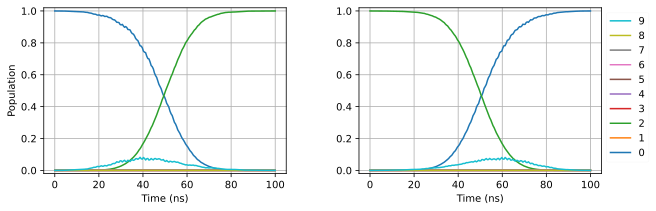

In [ ]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
#ax[0].plot(tlist, drive)
# fig.suptitle(state0+'-->'+state1 + ';  A=%.4f; '%drive_amp + '$\omega_d$=%.4f'%trans_freq )
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        ax[jdx].plot(tlist, np.array(res).flatten(), label=r"%d"%state)
    ax[jdx].set_ylim(-0.02,1.02)
    ax[jdx].grid()
    ax[jdx].set_xlabel('Time (ns)')
    # ax[idx][jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[1].set_xlabel('Time (ns)')
ax[0].set_ylabel('Population')
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles[::-1],labels[::-1],
            loc='upper left',
            bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)

In [ ]:
=

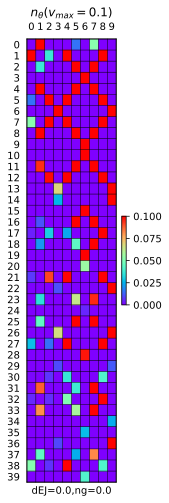

In [ ]:
fig, ax = plt.subplots(figsize=(2,8))
# font_size = 15
truc_x = 10
plt.imshow(np.abs(n_theta[:,:truc_x]), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'$n_{\theta}(v_{max}=$'+f'{vmax})' )
plt.xlabel('dEJ='+f'{dEJ}' + ',ng='+f'{ng}' )
ax.set_xticks(np.arange(0, truc_x, 1), np.arange(0, truc_x, 1))
ax.set_yticks(np.arange(0, truc, 1), np.arange(0, truc, 1))
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc_x, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.2)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

In [ ]:
# tg_vec = [50]
# argss = (w_trans_1, w_trans_2, states, H_qbt_drive)
# zpX.fidelity_de(tg_vec, argss)

#### all possible transitions for truc1=300

In [ ]:
w_trans = []
trans = []
trans_mat = []
for i, state_i in enumerate(hspace_indirect):
    for state_j in hspace_indirect[i:]:
        j = hspace_indirect.index(state_j)
        # print(state_i, state_j)
        if np.abs(drive_term[i, j]/(2*np.pi)) > thresh:
            w_trans.append(np.abs(evals[state_i] - evals[state_j]))
            transition = str(state_i) + '-' + str(state_j)
            trans.append(transition)
            trans_mat.append(np.abs(drive_term[i, j]/(2*np.pi)))
# for i, _ in enumerate(trans):
#     print(trans[i], w_trans[i])

sort_idx = np.argsort(w_trans)
w_trans = np.sort(np.round(w_trans, 3))
trans_mat = [np.round(trans_mat[i],3) for i in sort_idx]
trans = [trans[i] for i in sort_idx]

for i, _ in enumerate(trans):
    print(i, trans[i], w_trans[i], trans_mat[i])

0 283-284 0.0 1.91
1 131-132 0.0 6.301
2 289-290 0.0 6.537
3 221-222 0.001 1.474
4 150-151 0.003 4.879
5 231-232 0.005 5.143
6 251-252 0.007 7.272
7 106-107 0.009 2.163
8 195-196 0.01 1.463
9 87-88 0.028 3.884
10 133-134 0.044 6.171
11 236-237 0.046 2.607
12 97-98 0.051 0.269
13 207-208 0.055 0.537
14 297-298 0.063 0.734
15 64-65 0.067 1.51
16 186-187 0.069 6.246
17 278-281 0.075 3.052
18 225-226 0.08 3.977
19 270-271 0.093 0.84
20 263-264 0.096 4.941
21 218-220 0.104 1.328
22 30-31 0.177 1.625
23 188-191 0.278 5.153
24 188-192 0.278 0.557
25 121-122 0.338 5.171
26 210-213 0.663 5.771
27 247-248 0.695 6.59
28 72-74 0.72 1.296
29 31-32 0.74 3.249
30 298-299 0.892 4.509
31 102-107 0.896 0.1
32 120-121 0.912 0.868
33 45-47 0.914 1.899
34 46-48 1.05 1.341
35 258-259 1.065 4.474
36 271-274 1.072 7.268
37 230-232 1.19 0.67
38 127-128 1.216 2.411
39 59-62 1.296 3.279
40 156-157 1.382 3.267
41 292-296 1.446 2.523
42 285-288 1.459 7.082
43 155-158 1.462 2.629
44 171-175 1.481 0.95
45 63-64 1.56